In [1]:
# SciKit-Learn

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
iris = sns.load_dataset('iris')
print(iris.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
print(type(iris))

<class 'pandas.core.frame.DataFrame'>


In [5]:
print(type(iris.values))

<class 'numpy.ndarray'>


In [6]:
print(iris.shape)

(150, 5)


In [7]:
print(iris.columns)
print(iris.index)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
RangeIndex(start=0, stop=150, step=1)


In [8]:
plt.style.use('classic')

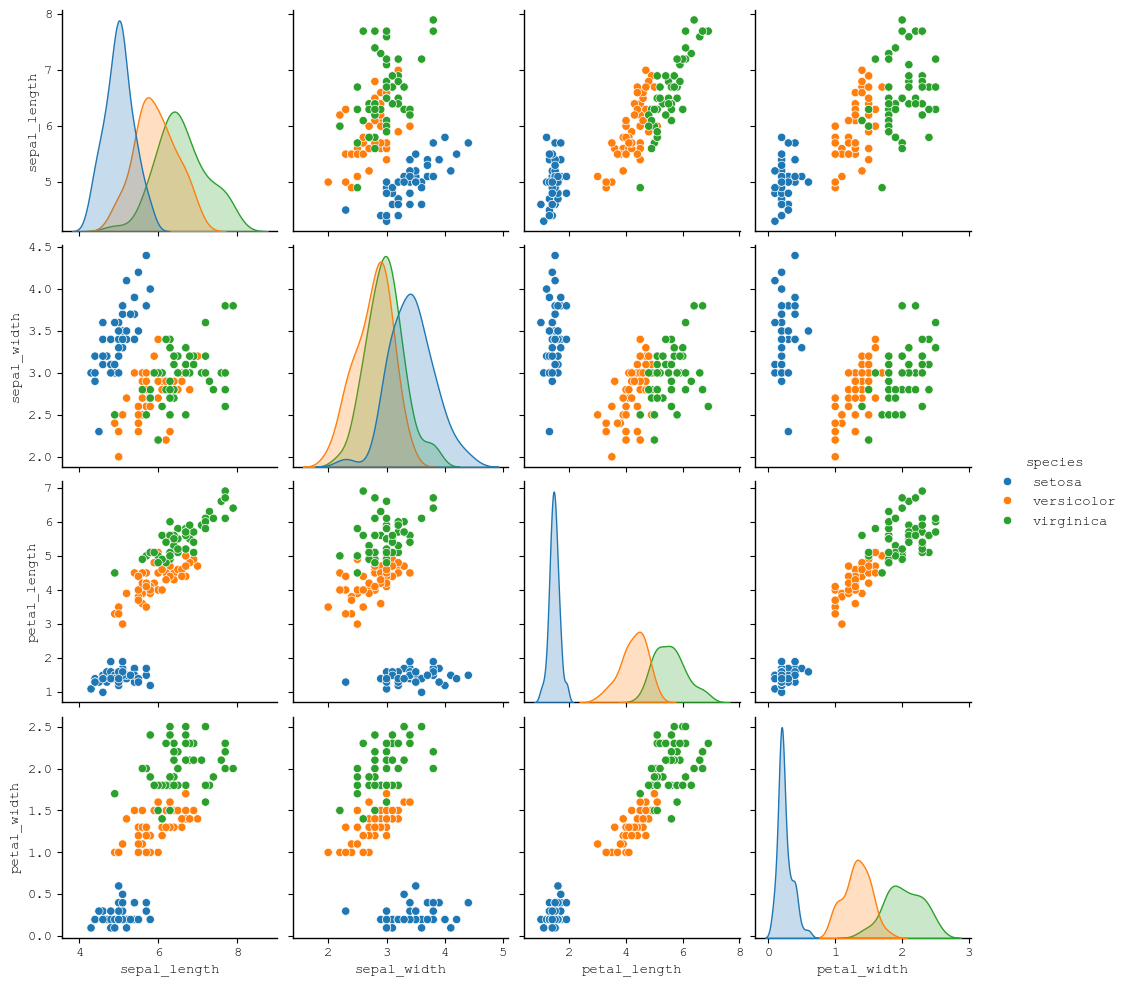

In [9]:
sns.pairplot(iris, hue='species')
plt.show()

In [10]:
# Строки - образцы - отдельный объект (sample)
# Столбцы - признаки (feature)
# Матрица признаков (число образцов на число признаков) - признаки - независимая переменная
# Целевой массив (target or label) [1 на число образцов] - зависимая переменная (зависит от признаков)

Матрица признаков (feature matrix) — это таблица (2D-массив), где строки соответствуют отдельным объектам (образцам), а столбцы — признакам (характеристикам), описывающим эти объекты. Обычно обозначается X. Например, в задаче с цветками ириса: длина чашелистика, ширина чашелистика, длина лепестка, ширина лепестка.

Целевой массив (target array) — это вектор (1D-массив), содержащий метки (целевые значения) для каждого объекта. Он показывает, какой ответ или класс соответствует каждому образцу. Обозначается y. Для ирисов — это вид цветка (setosa, versicolor, virginica).

Связь: задача обучения с учителем — найти закономерность X → y, чтобы по новым признакам предсказывать целевую переменную.

In [11]:
# Матрица признаков
X_iris = iris.drop('species', axis=1)
print(X_iris.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


In [12]:
# Целевой массив
y_iris = iris['species']
print(y_iris.head())

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


In [13]:
# 1. Выбирается класс модели
# 2. Выбираются гиперпараметры модели
# 3. На основе данных создаётся матрица признаков и целевой вектор
# 4. Обучение модели fit()
# 5. Обученная модель применяется к новым даным 
#   5.1. Обучение с учителем - predict()
#   5.2. Обучения без учителя - predict() или transform()

In [14]:
# С учителем. Регрессия. Линейная регрессия.

In [15]:
# 1. Выбирается класс модели
from sklearn.linear_model import LinearRegression

In [16]:
# 2. Выбираются гиперпараметры модели
model = LinearRegression(fit_intercept=True) 
# fit_intercept = False, Если из природы задачи или предметной области известно, что при 
# нулевых значениях всех признаков целевая переменная также должна быть равна нулю.

In [17]:
# 3. На основе данных создаётся матрица признаков и целевой вектор
x = iris[iris['species'] == 'setosa'].iloc[:, 0].to_numpy()
y = iris[iris['species'] == 'setosa'].iloc[:, 1].to_numpy()

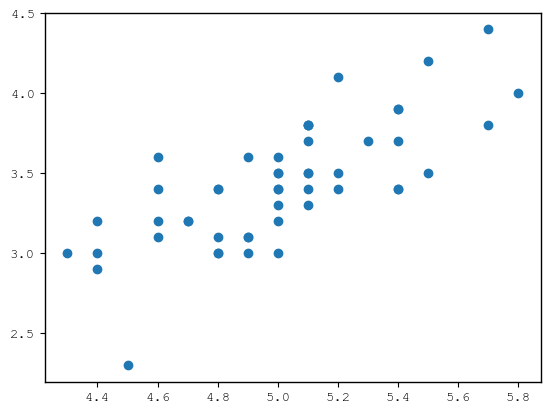

In [18]:
# 4. Обучение модели fit()
reg = model.fit(x[:, np.newaxis], y)

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = reg.predict(x_fit[:, np.newaxis])

plt.scatter(x, y)
plt.show()

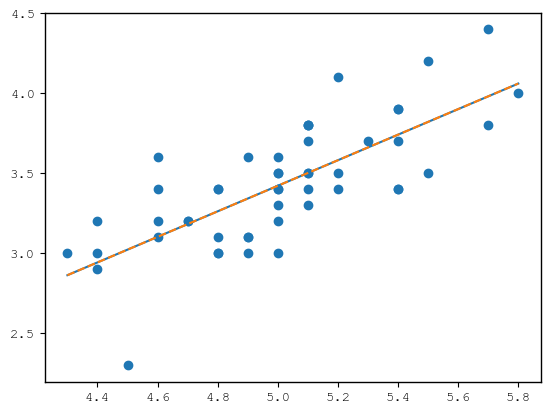

In [19]:
# 5. Обученная модель применяется к новым даным 
#   5.1. Обучение с учителем - predict()
x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = model.predict(x_fit[:, np.newaxis])

plt.scatter(x, y)
plt.plot(x_fit, y_fit)
plt.plot(x_fit, x_fit * reg.coef_ + reg.intercept_, '--') # the same: kx + b

plt.show()
# Конечно, работает не только для линейного случая

In [20]:
# Полиномиальная регрессия

In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [22]:
model = make_pipeline(PolynomialFeatures(7), LinearRegression())
reg = model.fit(x[:, np.newaxis], y)

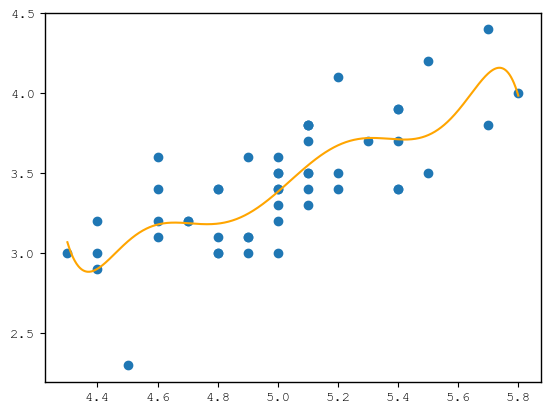

In [23]:
x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = model.predict(x_fit[:, np.newaxis])

plt.scatter(x, y)
plt.plot(x_fit, y_fit, color='orange')

plt.show()

In [24]:
print(iris.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [25]:
# Классификация. Логистическая регрессия

In [26]:
x_0 = iris[iris['species'] == 'setosa'].iloc[:, 0].to_numpy()
y_0 = iris[iris['species'] == 'setosa'].iloc[:, 1].to_numpy()

x_1 = iris[iris['species'] == 'versicolor'].iloc[:, 0].to_numpy()
y_1 = iris[iris['species'] == 'versicolor'].iloc[:, 1].to_numpy()

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [28]:
x = iris[iris['species'] != 'virginica'].iloc[:, 0].to_numpy()
print(x.shape)
y = iris[iris['species'] != 'virginica'].iloc[:, 4]
print(y.shape)

(100,)
(100,)


In [29]:
# Эта модель обучается предсказывать вид ириса (setosa или versicolor)
# по одному признаку — длине чашелистика (sepal length).
log_reg = model.fit(x[:, None], y)

In [30]:
xfit = np.linspace(x.min(), x.max(), 1000)
yfit = log_reg.predict_proba(xfit[:, None]) # с какой вероятностью первый или второй

In [31]:
print(yfit)

[[0.97313538 0.02686462]
 [0.97291008 0.02708992]
 [0.97268294 0.02731706]
 ...
 [0.00691071 0.99308929]
 [0.00685205 0.99314795]
 [0.00679388 0.99320612]]


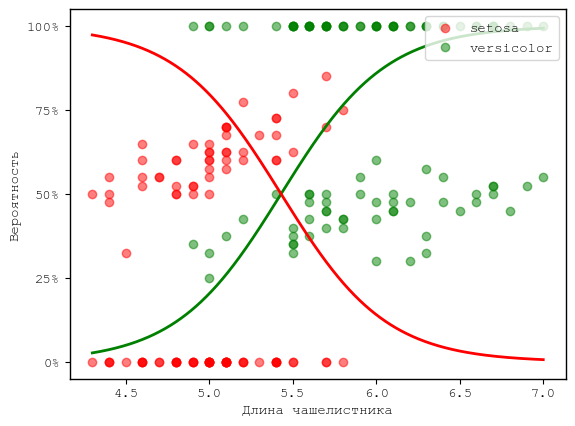

In [32]:
plt.scatter(x_0, y_0, color='red', alpha=0.5)
plt.scatter(x_1, y_1, color='green', alpha=0.5)

plt.scatter(x_0, np.full(50, 1), color='red', alpha=0.5, label='setosa')
plt.scatter(x_1, np.full(50, 5), color='green', alpha=0.5, label='versicolor')

plt.plot(xfit, 1 + 4 * yfit[:, 1], 'green', linewidth=2)
plt.plot(xfit, 1 + 4 * yfit[:, 0], 'red', linewidth=2)

plt.yticks([1, 2, 3, 4, 5], ['0%', '25%', '50%', '75%', '100%'])

plt.xlabel('Длина чашелистника')
plt.ylabel('Вероятность')

plt.legend(loc='upper right')

plt.show()

In [33]:
# Деревья решений

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
x = iris[iris['species'] != 'virginica'].iloc[:, 0:2].to_numpy()
y1 = np.full(50, 1)
y2 = np.full(50, 2)
y = np.ravel([y1, y2])

tree = DecisionTreeClassifier(max_depth=10)
tree.fit(x, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [36]:
print(np.c_[[1, 2, 3, 4, 5], [10, 20, 30, 40, 50]], end='\n\n')
print(np.ravel([[1, 2, 3, 4, 5], [10, 20, 30, 40, 50]]))

[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]
 [ 5 50]]

[ 1  2  3  4  5 10 20 30 40 50]


In [37]:
xx, yy = np.meshgrid(
    np.linspace(x[:, 0].min(), x[:, 0].max(), 100),
    np.linspace(x[:, 1].min(), x[:, 1].max(), 100)   
)

In [38]:
Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

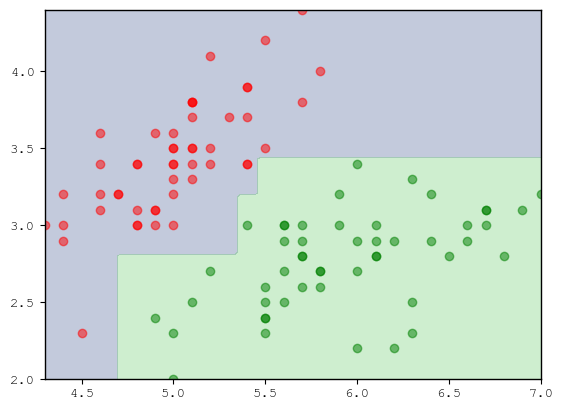

In [39]:
ax = plt.gca()

ax.contourf(xx, yy, Z, alpha=0.3, levels=[0, 1.5, 3])

ax.scatter(x_0, y_0, color='red', alpha=0.5)
ax.scatter(x_1, y_1, color='green', alpha=0.5)

plt.show()